# Computer Vision - Lab Sheet 3

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, clear_output
import ipywidgets as widgets

plt.rcParams["figure.figsize"] = (12, 6)

print("OpenCV version:", cv2.__version__)
print("Setup complete.")

OpenCV version: 5.0.0
Setup complete.


In [ ]:
plt.rcParams["figure.figsize"] = (12, 6)

def load_image(path):
    """Load an image as RGB."""
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def select_image_for_program():
    """Helper function to select an image via upload or local path."""
    image_path = None
    try:
        from google.colab import files
        print("Please upload an image for this program:")
        uploaded = files.upload()
        image_path = next(iter(uploaded))
    except Exception:
        image_path = input("Enter image path for this program: ")
    return load_image(image_path)


def show_images(images, titles, figsize=(16, 5)):
    """Display multiple RGB/grayscale images side by side."""
    plt.figure(figsize=figsize)
    for i, (image, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if len(image.shape) == 2:
            plt.imshow(image, cmap="gray")
        else:
            plt.imshow(image)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper_noise(image, amount=10, seed=42):
    """Add salt-and-pepper noise to an RGB image."""
    rng = np.random.default_rng(seed)
    noisy = image.copy()

    h, w = image.shape[:2]
    n = int(h * w * amount / 100)

    rows = rng.integers(0, h, n)
    cols = rng.integers(0, w, n)

    half = n // 2
    noisy[rows[:half], cols[:half]] = 255
    noisy[rows[half:], cols[half:]] = 0

    return noisy


def calculate_psnr(original, filtered):
    """Calculate PSNR in dB."""
    original = original.astype(np.float64)
    filtered = filtered.astype(np.float64)

    mse = np.mean((original - filtered) ** 2)

    if mse == 0:
        return float("inf")

    return 10 * np.log10((255 ** 2) / mse)


def calculate_ssim(original, filtered):
    """Calculate SSIM for RGB images."""
    return ssim(
        original,
        filtered,
        channel_axis=2,
        data_range=255
    )


print("Helper functions loaded.")

Helper functions loaded.


# 1. Noise Removal: Gaussian, Median and Mean Filters


Please upload an image for this program:


Saving pngtree-beautiful-garden-flowers-hd-background-wallpaper-vibrant-desktop-picture-image_15834668.jpg to pngtree-beautiful-garden-flowers-hd-background-wallpaper-vibrant-desktop-picture-image_15834668.jpg


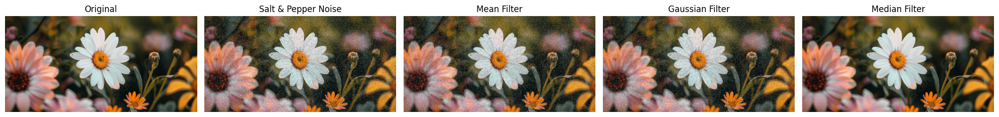

In [ ]:
program1_image = select_image_for_program()

noise_amount = 10
noisy = add_salt_pepper_noise(program1_image, noise_amount)

# Convert RGB -> BGR for OpenCV
noisy_bgr = cv2.cvtColor(noisy, cv2.COLOR_RGB2BGR)

kernel_size = 3

mean_result = cv2.blur(
    noisy_bgr,
    (kernel_size, kernel_size)
)

gaussian_result = cv2.GaussianBlur(
    noisy_bgr,
    (kernel_size, kernel_size),
    0
)

median_result = cv2.medianBlur(
    noisy_bgr,
    kernel_size
)

mean_rgb = cv2.cvtColor(mean_result, cv2.COLOR_BGR2RGB)
gaussian_rgb = cv2.cvtColor(gaussian_result, cv2.COLOR_BGR2RGB)
median_rgb = cv2.cvtColor(median_result, cv2.COLOR_BGR2RGB)

show_images(
    [program1_image, noisy, mean_rgb, gaussian_rgb, median_rgb],
    [
        "Original",
        "Salt & Pepper Noise",
        "Mean Filter",
        "Gaussian Filter",
        "Median Filter"
    ],
    figsize=(20, 5)
)

## 2. Edge Detection Using Sobel and Laplacian

Please upload an image for this program:


Saving image_9c5ab6c3.jpg to image_9c5ab6c3.jpg


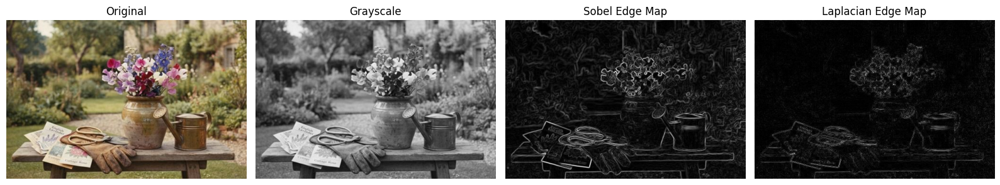

Sobel X kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Laplacian kernel:
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


In [ ]:
program2_image = select_image_for_program()

gray = cv2.cvtColor(program2_image, cv2.COLOR_RGB2GRAY)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
sobel_edges = cv2.normalize(
    sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

laplacian = cv2.Laplacian(
    gray,
    cv2.CV_64F,
    ksize=3
)

laplacian_edges = cv2.normalize(
    np.abs(laplacian),
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

show_images(
    [program2_image, gray, sobel_edges, laplacian_edges],
    [
        "Original",
        "Grayscale",
        "Sobel Edge Map",
        "Laplacian Edge Map"
    ],
    figsize=(16, 5)
)

print("Sobel X kernel:")
print(np.array([[-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]]))

print("\nLaplacian kernel:")
print(np.array([[0, 1, 0],
                [1, -4, 1],
                [0, 1, 0]]))


# 3. Interactive Low-Pass Blur Tool

In [ ]:
program3_image = select_image_for_program()

def interactive_blur(image):
    slider = widgets.IntSlider(
        value=5,
        min=3,
        max=31,
        step=2,
        description="Kernel:",
        continuous_update=True
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            k = slider.value
            blurred = cv2.blur(
                image,
                (k, k)
            )

            show_images(
                [image, blurred],
                ["Original", f"Mean Low-Pass Blur ({k}x{k})"],
                figsize=(12, 5)
            )

    slider.observe(update, names="value")
    update()

    display(slider, output)


interactive_blur(program3_image)

Please upload an image for this program:


Saving old.png to old.png


IntSlider(value=5, description='Kernel:', max=31, min=3, step=2)

Output()

# 4. Sharpening Using Unsharp Masking

In [ ]:
program4_image = select_image_for_program()

def interactive_unsharp(image):
    kernel_slider = widgets.IntSlider(
        value=5,
        min=3,
        max=31,
        step=2,
        description="Kernel:",
        continuous_update=True
    )

    strength_slider = widgets.FloatSlider(
        value=1.5,
        min=0,
        max=5,
        step=0.1,
        description="Strength:",
        continuous_update=True
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            k = kernel_slider.value
            strength = strength_slider.value

            blurred = cv2.GaussianBlur(
                image,
                (k, k),
                0
            )

            sharpened = cv2.addWeighted(
                image,
                1 + strength,
                blurred,
                -strength,
                0
            )

            sharpened = np.clip(
                sharpened,
                0,
                255
            ).astype(np.uint8)

            show_images(
                [image, blurred, sharpened],
                [
                    "Original",
                    f"Gaussian Blur ({k}x{k})",
                    f"Unsharp Masking (Strength={strength:.1f})"
                ],
                figsize=(16, 5)
            )

    kernel_slider.observe(update, names="value")
    strength_slider.observe(update, names="value")
    update()

    display(kernel_slider, strength_slider, output)


interactive_unsharp(program4_image)

Please upload an image for this program:


Saving image_9c5ab6c3.jpg to image_9c5ab6c3 (2).jpg


IntSlider(value=5, description='Kernel:', max=31, min=3, step=2)

FloatSlider(value=1.5, description='Strength:', max=5.0)

Output()

# 5. Custom Convolution Kernel Designer

In [ ]:
program5_image = select_image_for_program()

def apply_custom_kernel(image, kernel):
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    result = cv2.filter2D(
        image_bgr,
        -1,
        kernel.astype(np.float32)
    )
    return cv2.cvtColor(result, cv2.COLOR_BGR2RGB)


preset_kernels = {
    "Identity": np.array(
        [[0, 0, 0],
         [0, 1, 0],
         [0, 0, 0]],
        dtype=np.float32
    ),

    "Blur": np.ones((3, 3), dtype=np.float32) / 9,

    "Sharpen": np.array(
        [[0, -1, 0],
         [-1, 5, -1],
         [0, -1, 0]],
        dtype=np.float32
    ),

    "Edge Detection": np.array(
        [[-1, -1, -1],
         [-1, 8, -1],
         [-1, -1, -1]],
        dtype=np.float32
    ),

    "Sobel X": np.array(
        [[-1, 0, 1],
         [-2, 0, 2],
         [-1, 0, 1]],
        dtype=np.float32
    ),

    "Sobel Y": np.array(
        [[-1, -2, -1],
         [0, 0, 0],
         [1, 2, 1]],
        dtype=np.float32
    ),

    "Emboss": np.array(
        [[-2, -1, 0],
         [-1, 1, 1],
         [0, 1, 2]],
        dtype=np.float32
    )
}

preset_dropdown = widgets.Dropdown(
    options=list(preset_kernels.keys()),
    description="Preset:"
)

kernel_text = widgets.Textarea(
    value=np.array2string(
        preset_kernels["Identity"],
        separator=" "
    ),
    description="Kernel:",
    layout=widgets.Layout(width="500px", height="120px")
)

button = widgets.Button(
    description="Apply Kernel",
    button_style="primary"
)

output = widgets.Output()

def parse_kernel(text):
    rows = []
    for line in text.strip().splitlines():
        line = line.replace("[", "").replace("]", "")
        values = [float(x) for x in line.replace(",", " ").split()]
        if values:
            rows.append(values)

    if not rows:
        raise ValueError("Kernel is empty.")

    if len(set(len(row) for row in rows)) != 1:
        raise ValueError("All kernel rows must have the same length.")

    kernel = np.array(rows, dtype=np.float32)

    if kernel.shape[0] != kernel.shape[1]:
        raise ValueError("Kernel must be square.")

    if kernel.shape[0] % 2 == 0:
        raise ValueError("Kernel size must be odd.")

    return kernel


def update_kernel_text(change):
    kernel = preset_kernels[change["new"]]
    kernel_text.value = np.array2string(
        kernel,
        separator=" "
    )


def apply_kernel(_):
    with output:
        clear_output(wait=True)

        try:
            kernel = parse_kernel(kernel_text.value)
            result = apply_custom_kernel(program5_image, kernel)

            print("Kernel:")
            print(kernel)

            show_images(
                [program5_image, result],
                ["Original", "Custom Convolution Result"],
                figsize=(12, 5)
            )

        except Exception as e:
            print("Error:", e)


preset_dropdown.observe(
    update_kernel_text,
    names="value"
)

button.on_click(apply_kernel)

display(
    preset_dropdown,
    kernel_text,
    button,
    output
)

Please upload an image for this program:


Saving image_9c5ab6c3.jpg to image_9c5ab6c3 (1).jpg


Dropdown(description='Preset:', options=('Identity', 'Blur', 'Sharpen', 'Edge Detection', 'Sobel X', 'Sobel Y'…

Textarea(value='[[0. 0. 0.]\n [0. 1. 0.]\n [0. 0. 0.]]', description='Kernel:', layout=Layout(height='120px', …

Button(button_style='primary', description='Apply Kernel', style=ButtonStyle())

Output()

# 6. Bilateral Filtering vs Gaussian Blur


In [ ]:
program6_image = select_image_for_program()

def interactive_bilateral_comparison(image):
    gaussian_k = widgets.IntSlider(
        value=9, min=3, max=31, step=2,
        description="Gaussian:"
    )

    gaussian_sigma = widgets.FloatSlider(
        value=2.0, min=0.1, max=10, step=0.1,
        description="G Sigma:"
    )

    bilateral_d = widgets.IntSlider(
        value=9, min=3, max=15, step=2,
        description="Bilateral:"
    )

    sigma_color = widgets.IntSlider(
        value=75, min=1, max=150, step=1,
        description="Sigma Color:"
    )

    sigma_space = widgets.IntSlider(
        value=75, min=1, max=150, step=1,
        description="Sigma Space:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            g = cv2.GaussianBlur(
                image,
                (gaussian_k.value, gaussian_k.value),
                gaussian_sigma.value
            )

            bgr = cv2.cvtColor(
                image,
                cv2.COLOR_RGB2BGR
            )

            b = cv2.bilateralFilter(
                bgr,
                bilateral_d.value,
                sigma_color.value,
                sigma_space.value
            )

            b = cv2.cvtColor(
                b,
                cv2.COLOR_BGR2RGB
            )

            show_images(
                [image, g, b],
                [
                    "Original",
                    "Gaussian Blur",
                    "Bilateral Filter"
                ],
                figsize=(16, 5)
            )

    for w in [
        gaussian_k,
        gaussian_sigma,
        bilateral_d,
        sigma_color,
        sigma_space
    ]:
        w.observe(update, names="value")

    update()

    display(
        gaussian_k,
        gaussian_sigma,
        bilateral_d,
        sigma_color,
        sigma_space,
        output
    )


interactive_bilateral_comparison(program6_image)

Please upload an image for this program:


Saving landscape.png to landscape.png


IntSlider(value=9, description='Gaussian:', max=31, min=3, step=2)

FloatSlider(value=2.0, description='G Sigma:', max=10.0, min=0.1)

IntSlider(value=9, description='Bilateral:', max=15, min=3, step=2)

IntSlider(value=75, description='Sigma Color:', max=150, min=1)

IntSlider(value=75, description='Sigma Space:', max=150, min=1)

Output()

# 7. Denoising Pipeline for Old/Scanned Photographs


Please upload an image for this program:


Saving old.png to old (1).png


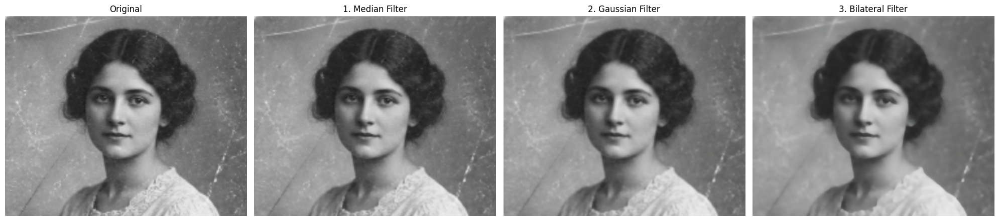

In [ ]:
program7_image = select_image_for_program()

def denoising_pipeline(image, median_k=3, gaussian_k=5,
                       gaussian_sigma=1.0,
                       bilateral_d=9,
                       sigma_color=50,
                       sigma_space=50):

    bgr = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    stage1 = cv2.medianBlur(
        bgr,
        median_k
    )

    stage2 = cv2.GaussianBlur(
        stage1,
        (gaussian_k, gaussian_k),
        gaussian_sigma
    )

    stage3 = cv2.bilateralFilter(
        stage2,
        bilateral_d,
        sigma_color,
        sigma_space
    )

    return [
        image,
        cv2.cvtColor(stage1, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(stage2, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(stage3, cv2.COLOR_BGR2RGB)
    ]


pipeline_images = denoising_pipeline(program7_image)

show_images(
    pipeline_images,
    [
        "Original",
        "1. Median Filter",
        "2. Gaussian Filter",
        "3. Bilateral Filter"
    ],
    figsize=(20, 5)
)

# 8. Motion-Blur Reduction Using High-Pass Sharpening



In [ ]:
program8_image = select_image_for_program()

def high_pass_sharpen(image, kernel_size=5, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(
        image,
        (kernel_size, kernel_size),
        sigma
    )

    high_pass = image.astype(np.float32) - blurred.astype(np.float32)

    sharpened = image.astype(np.float32) + strength * high_pass

    sharpened = np.clip(
        sharpened,
        0,
        255
    ).astype(np.uint8)

    high_pass_display = cv2.normalize(
        np.abs(high_pass),
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return blurred, high_pass_display, sharpened


def interactive_motion_sharpen(image):
    kernel_slider = widgets.IntSlider(
        value=5, min=3, max=31, step=2,
        description="Kernel:"
    )

    sigma_slider = widgets.FloatSlider(
        value=1.0, min=0.1, max=10, step=0.1,
        description="Sigma:"
    )

    strength_slider = widgets.FloatSlider(
        value=1.5, min=0, max=5, step=0.1,
        description="Strength:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            blurred, high_pass, sharpened = high_pass_sharpen(
                image,
                kernel_slider.value,
                sigma_slider.value,
                strength_slider.value
            )

            show_images(
                [image, high_pass, sharpened],
                [
                    "Input",
                    "High-Pass Detail",
                    "Sharpened Output"
                ],
                figsize=(16, 5)
            )

    for w in [
        kernel_slider,
        sigma_slider,
        strength_slider
    ]:
        w.observe(update, names="value")

    update()

    display(
        kernel_slider,
        sigma_slider,
        strength_slider,
        output
    )


interactive_motion_sharpen(program8_image)

Please upload an image for this program:


Saving old.png to old (2).png


IntSlider(value=5, description='Kernel:', max=31, min=3, step=2)

FloatSlider(value=1.0, description='Sigma:', max=10.0, min=0.1)

FloatSlider(value=1.5, description='Strength:', max=5.0)

Output()

# 9. Cartoonify Effect Generator

Please upload an image for this program:


Saving ChatGPT Image Sep 14, 2026, 12_24_23 PM.png to ChatGPT Image Sep 14, 2026, 12_24_23 PM.png


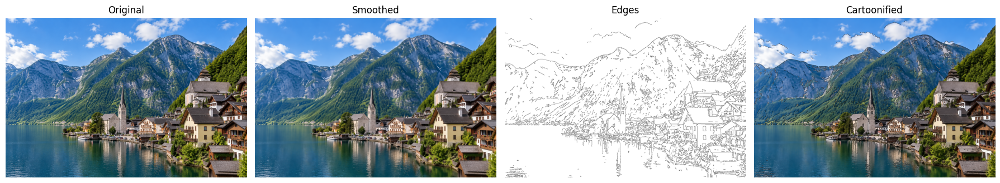

In [ ]:
program9_image = select_image_for_program()

def cartoonify(image,
               bilateral_d=9,
               sigma_color=75,
               sigma_space=75,
               median_k=5,
               threshold1=100,
               threshold2=200):

    bgr = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    # Smooth colors while preserving edges
    smooth = cv2.bilateralFilter(
        bgr,
        bilateral_d,
        sigma_color,
        sigma_space
    )

    # Prepare grayscale image for edge detection
    gray = cv2.cvtColor(
        bgr,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.medianBlur(
        gray,
        median_k
    )

    # Detect edges
    edges = cv2.Canny(
        gray,
        threshold1,
        threshold2
    )

    # Invert edges: edges become black
    edges = cv2.bitwise_not(edges)

    # Convert mask to 3 channels
    edges_color = cv2.cvtColor(
        edges,
        cv2.COLOR_GRAY2BGR
    )

    # Combine smooth colors and edge mask
    cartoon = cv2.bitwise_and(
        smooth,
        edges_color
    )

    return (
        cv2.cvtColor(smooth, cv2.COLOR_BGR2RGB),
        edges,
        cv2.cvtColor(cartoon, cv2.COLOR_BGR2RGB)
    )


smooth, cartoon_edges, cartoon_result = cartoonify(program9_image)

show_images(
    [
        program9_image,
        smooth,
        cartoon_edges,
        cartoon_result
    ],
    [
        "Original",
        "Smoothed",
        "Edges",
        "Cartoonified"
    ],
    figsize=(18, 5)
)

## Interactive Cartoonify Controls

In [ ]:
program9_image_interactive = select_image_for_program()

def interactive_cartoon(image):
    bilateral_d = widgets.IntSlider(
        value=9, min=5, max=15, step=2,
        description="Diameter:"
    )

    sigma_color = widgets.IntSlider(
        value=75, min=10, max=200, step=5,
        description="Sigma Color:"
    )

    sigma_space = widgets.IntSlider(
        value=75, min=10, max=200, step=5,
        description="Sigma Space:"
    )

    threshold1 = widgets.IntSlider(
        value=100, min=0, max=255, step=5,
        description="Threshold 1:"
    )

    threshold2 = widgets.IntSlider(
        value=200, min=0, max=255, step=5,
        description="Threshold 2:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            smooth, edges, result = cartoonify(
                image,
                bilateral_d.value,
                sigma_color.value,
                sigma_space.value,
                5,
                threshold1.value,
                threshold2.value
            )

            show_images(
                [image, smooth, edges, result],
                [
                    "Original",
                    "Smoothed",
                    "Edge Map",
                    "Cartoonified"
                ],
                figsize=(18, 5)
            )

    for w in [
        bilateral_d,
        sigma_color,
        sigma_space,
        threshold1,
        threshold2
    ]:
        w.observe(update, names="value")

    update()

    display(
        bilateral_d,
        sigma_color,
        sigma_space,
        threshold1,
        threshold2,
        output
    )


interactive_cartoon(program9_image_interactive)

Please upload an image for this program:


Saving image_9c5ab6c3.jpg to image_9c5ab6c3 (3).jpg


IntSlider(value=9, description='Diameter:', max=15, min=5, step=2)

IntSlider(value=75, description='Sigma Color:', max=200, min=10, step=5)

IntSlider(value=75, description='Sigma Space:', max=200, min=10, step=5)

IntSlider(value=100, description='Threshold 1:', max=255, step=5)

IntSlider(value=200, description='Threshold 2:', max=255, step=5)

Output()

# 10. PSNR/SSIM Filtering Comparison Dashboard



Please upload an image for this program:


Saving 360_F_931253580_joxM2UFY5VuV6qaRvOKmg3CiXv2i3oE8.jpg to 360_F_931253580_joxM2UFY5VuV6qaRvOKmg3CiXv2i3oE8 (4).jpg


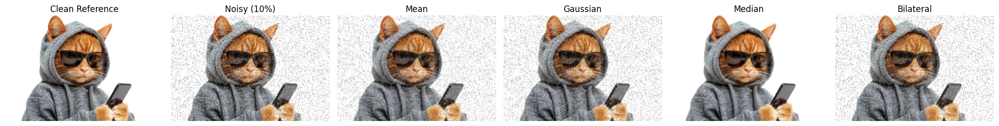

,Filter,PSNR (dB),SSIM
2,Median Filter,29.13,0.9067
0,Mean Filter,21.51,0.4084
1,Gaussian Filter,21.06,0.4056
3,Bilateral Filter,13.98,0.2161


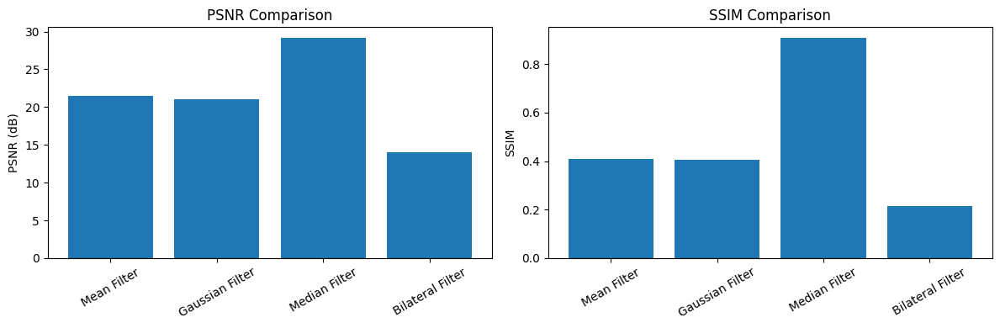

Best PSNR: Median Filter
Best SSIM: Median Filter


In [ ]:
program10_image = select_image_for_program()

def comparison_dashboard(
    clean_image,
    noise_amount=10,
    kernel_size=3,
    bilateral_d=9,
    sigma_color=75,
    sigma_space=75
):

    # Fixed seed makes the noisy input identical for every filter
    noisy = add_salt_pepper_noise(
        clean_image,
        noise_amount,
        seed=42
    )

    noisy_bgr = cv2.cvtColor(
        noisy,
        cv2.COLOR_RGB2BGR
    )

    # Apply filters to the SAME noisy image
    mean_result = cv2.blur(
        noisy_bgr,
        (kernel_size, kernel_size)
    )

    gaussian_result = cv2.GaussianBlur(
        noisy_bgr,
        (kernel_size, kernel_size),
        0
    )

    median_result = cv2.medianBlur(
        noisy_bgr,
        kernel_size
    )

    bilateral_result = cv2.bilateralFilter(
        noisy_bgr,
        bilateral_d,
        sigma_color,
        sigma_space
    )

    results = {
        "Mean Filter": cv2.cvtColor(
            mean_result,
            cv2.COLOR_BGR2RGB
        ),
        "Gaussian Filter": cv2.cvtColor(
            gaussian_result,
            cv2.COLOR_BGR2RGB
        ),
        "Median Filter": cv2.cvtColor(
            median_result,
            cv2.COLOR_BGR2RGB
        ),
        "Bilateral Filter": cv2.cvtColor(
            bilateral_result,
            cv2.COLOR_BGR2RGB
        )
    }

    # Calculate scores
    rows = []

    for name, result in results.items():
        rows.append({
            "Filter": name,
            "PSNR (dB)": calculate_psnr(
                clean_image,
                result
            ),
            "SSIM": calculate_ssim(
                clean_image,
                result
            )
        })

    scores = pd.DataFrame(rows)

    # Display images
    show_images(
        [
            clean_image,
            noisy,
            results["Mean Filter"],
            results["Gaussian Filter"],
            results["Median Filter"],
            results["Bilateral Filter"]
        ],
        [
            "Clean Reference",
            f"Noisy ({noise_amount}%)",
            "Mean",
            "Gaussian",
            "Median",
            "Bilateral"
        ],
        figsize=(20, 7)
    )

    # Display scores
    scores_display = scores.copy()
    scores_display["PSNR (dB)"] = scores_display[
        "PSNR (dB)"
    ].round(2)
    scores_display["SSIM"] = scores_display[
        "SSIM"
    ].round(4)

    scores_display = scores_display.sort_values(
        "PSNR (dB)",
        ascending=False
    )

    display(scores_display)

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(
        scores["Filter"],
        scores["PSNR (dB)"]
    )
    axes[0].set_title("PSNR Comparison")
    axes[0].set_ylabel("PSNR (dB)")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(
        scores["Filter"],
        scores["SSIM"]
    )
    axes[1].set_title("SSIM Comparison")
    axes[1].set_ylabel("SSIM")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    best_psnr = scores.loc[
        scores["PSNR (dB)"].idxmax(),
        "Filter"
    ]

    best_ssim = scores.loc[
        scores["SSIM"].idxmax(),
        "Filter"
    ]

    print("Best PSNR:", best_psnr)
    print("Best SSIM:", best_ssim)

    return scores


comparison_scores = comparison_dashboard(
    program10_image,
    noise_amount=10,
    kernel_size=3,
    bilateral_d=9,
    sigma_color=75,
    sigma_space=75
)